In [2]:
import pickle
import numpy as np
import os

def load_cifar_batch(filepath):
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    images = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b'labels'])
    return images, labels

data_dir = os.path.expanduser('~/.keras/datasets/cifar-10-batches-py')

X_train_list, y_train_list = [], []
for i in range(1, 6):
    imgs, lbls = load_cifar_batch(os.path.join(data_dir, f'data_batch_{i}'))
    X_train_list.append(imgs)
    y_train_list.append(lbls)

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_test, y_test = load_cifar_batch(os.path.join(data_dir, 'test_batch'))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


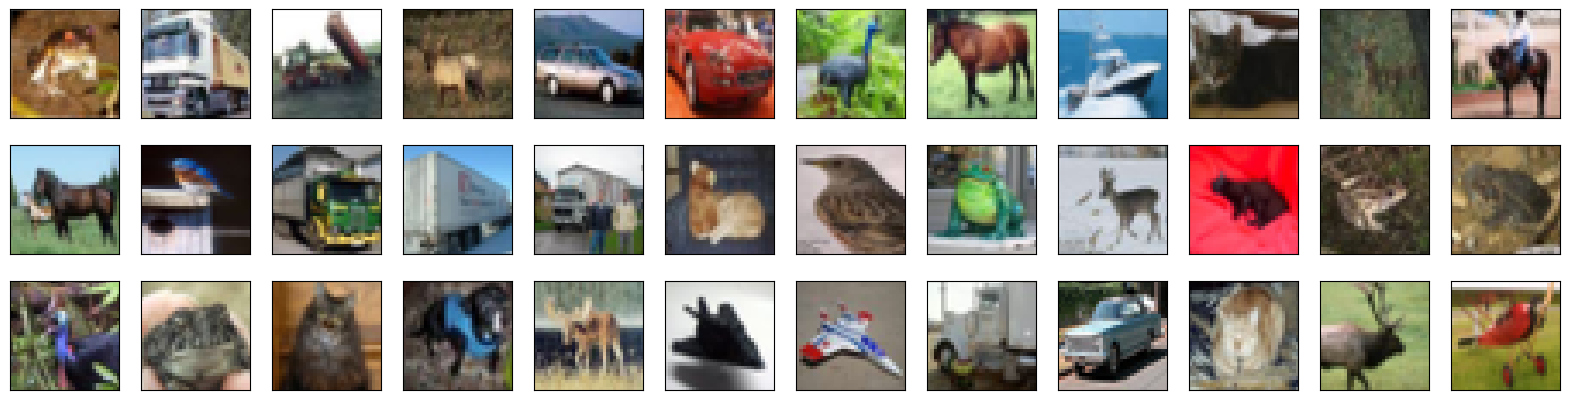

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3,12 , i+1 , xticks=[] , yticks=[])
    ax.imshow(np.squeeze(X_train[i]))

In [4]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

In [5]:
from tensorflow.keras.utils import to_categorical
from tensorflow import keras

num_classes = len(np.unique(y_train))

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

(X_train, X_valid) = X_train[5000:], X_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

print('X_train shape:', X_train.shape)

print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')
print(X_valid.shape[0], 'validation samples')

X_train shape: (45000, 32, 32, 3)
45000 train samples
10000 test samples
5000 validation samples


In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(filters=16 , kernel_size=3 , padding='same' , activation='relu' , input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,094 (2.06 MB)

 Trainable params: 541,094 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss = 'categorical_crossentropy' , optimizer='rmsprop' , metrics=['accuracy'])


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpointer = ModelCheckpoint(filepath='model.best.keras',verbose=1,save_best_only=True)

hist = model.fit(X_train , y_train , batch_size=64 , epochs=20 , validation_data=(X_test , y_test) , callbacks=[checkpointer],verbose=2,shuffle=True)

Epoch 1/20

Epoch 1: val_loss improved from None to 0.81646, saving model to model.best.keras

Epoch 1: finished saving model to model.best.keras
704/704 - 9s - 12ms/step - accuracy: 0.7432 - loss: 0.7420 - val_accuracy: 0.7216 - val_loss: 0.8165
Epoch 2/20

Epoch 2: val_loss did not improve from 0.81646
704/704 - 8s - 12ms/step - accuracy: 0.7484 - loss: 0.7240 - val_accuracy: 0.7076 - val_loss: 0.8784
Epoch 3/20

Epoch 3: val_loss did not improve from 0.81646
704/704 - 8s - 12ms/step - accuracy: 0.7558 - loss: 0.7075 - val_accuracy: 0.6560 - val_loss: 1.0521
Epoch 4/20

Epoch 4: val_loss did not improve from 0.81646
704/704 - 8s - 12ms/step - accuracy: 0.7619 - loss: 0.6940 - val_accuracy: 0.7091 - val_loss: 0.8864
Epoch 5/20

Epoch 5: val_loss did not improve from 0.81646
704/704 - 8s - 12ms/step - accuracy: 0.7670 - loss: 0.6777 - val_accuracy: 0.6763 - val_loss: 0.9759
Epoch 6/20

Epoch 6: val_loss did not improve from 0.81646
704/704 - 8s - 12ms/step - accuracy: 0.7688 - loss: 0.

In [18]:
score = model.evaluate(X_test, y_test , verbose=0)
#accuracy=100*score[1]
print('Test accuracy: ' ,score[1])

Test accuracy:  0.7493000030517578


In [19]:
# get predictions on the test set
y_hat = model.predict(X_test)

# define text labels (source: https://www.cs.toronto.edu/~kriz/cifar.html)
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


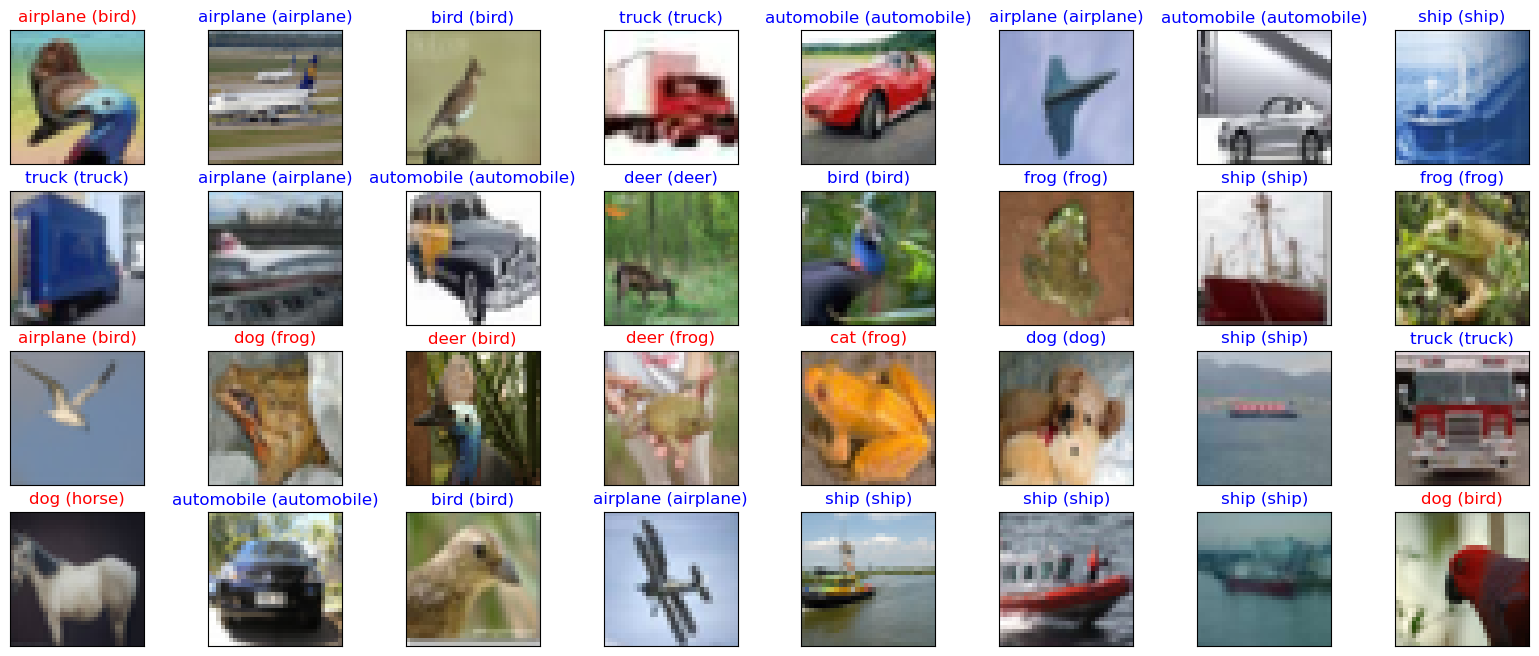

In [20]:
fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(X_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[idx]))
    pred_idx = np.argmax(y_hat[idx])
    true_idx = np.argmax(y_test[idx])
    ax.set_title("{} ({})".format(cifar10_labels[pred_idx], cifar10_labels[true_idx]),
                 color=("blue" if pred_idx == true_idx else "red"))